In [2]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0, delta_ppm, eta, CQ_M, Qeta, alpha, beta, gamma, QPAS, Siso_ppm, Siso, QXG, CsaQXG, AcsQXG
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
import sympy as sym
from sympy import *

#(https://pages.nyu.edu/jerschow/NMRmap/NMRmap_deployed.html)

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


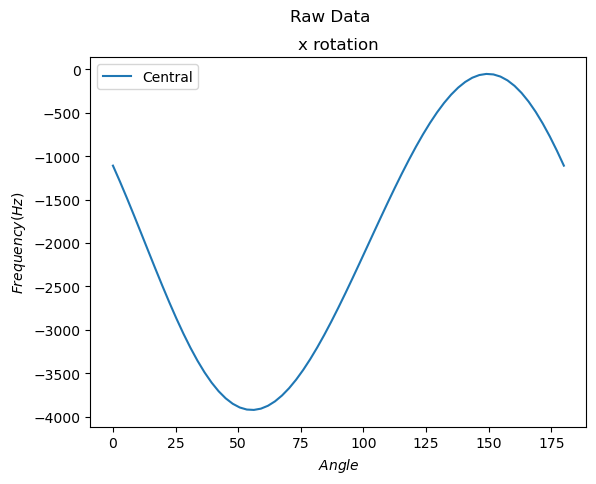

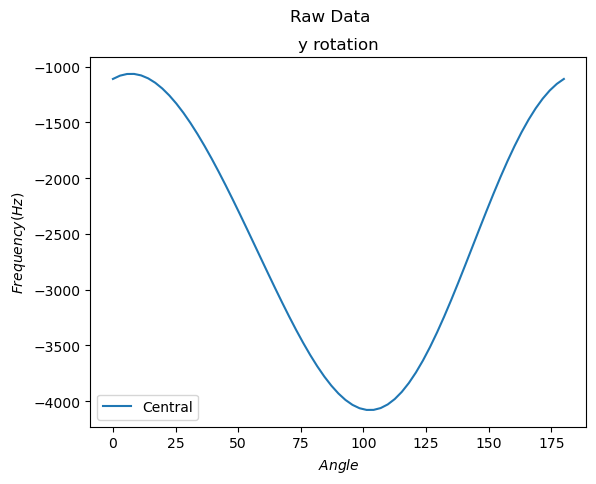

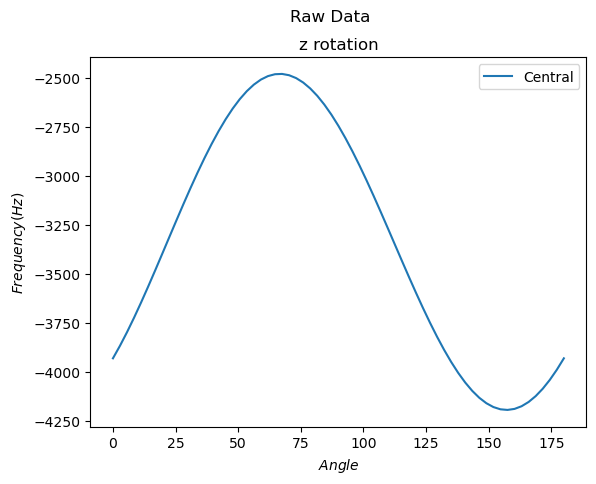

In [3]:
titles = ['x rotation', 'y rotation', 'z rotation']
df = [0]*len(titles)
set = 1             #which set to analyse
file_path = ('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_simulation/')

for i, orientation in enumerate(titles):
    file_name = f'{orientation}_set{set}_B.csv'
    df[i] = pd.read_csv(file_path+file_name, index_col=0)
    # plt.plot(df[i].angle, df[i].freq_3212, label = 'Satellite1')
    plt.plot(df[i].angle, df[i].freq_1212, label = 'Central')
    # plt.plot(df[i].angle, df[i].freq_1232, label = 'Satellite2')
    plt.suptitle('Raw Data')
    plt.title(titles[i])
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    plt.legend()
    plt.show()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.183e-21 (chi2/ndof = 0.0)│              Nfcn = 149              │
│ EDM = 2.75e-23 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

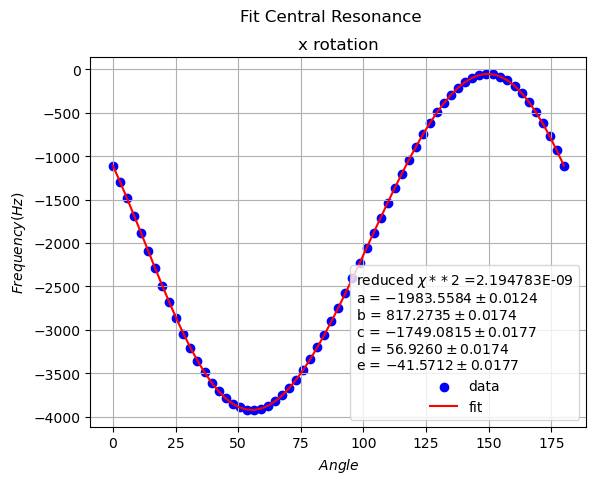

a = -1983.5583659231597
b = 817.2734775426329
c = -1749.0815161845394
d = 56.925990644362
e = -41.57119611195392
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.903e-21 (chi2/ndof = 0.0)│              Nfcn = 149              │
│ EDM = 4e-23 (Goal: 0.0002)       │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴───

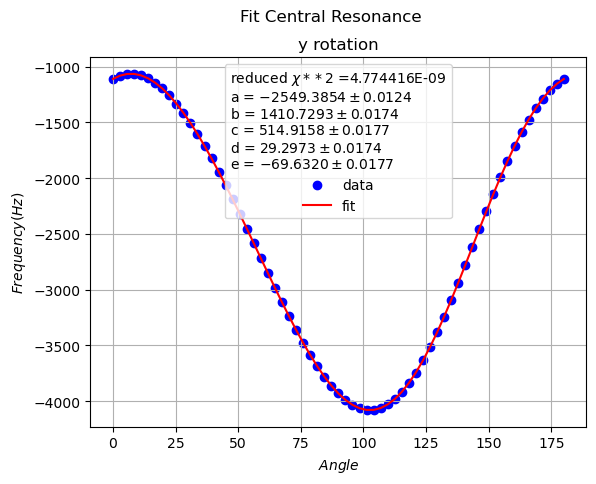

a = -2549.3854462666195
b = 1410.729285626668
c = 514.9158055564948
d = 29.297262903786514
e = -69.63200033563369
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.468e-21 (chi2/ndof = 0.0)│              Nfcn = 145              │
│ EDM = 1.93e-22 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴──

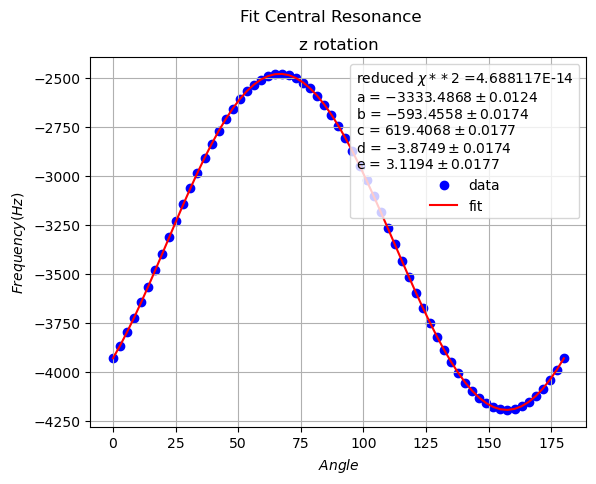

a = -3333.4867969260963
b = -593.4558080840353
c = 619.4068171136295
d = -3.8748639793693456
e = 3.1194075943089694


In [4]:
m_Q = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].angle, df[i].freq_1212, 0.1,fourier5)
    
    m_Q[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_Q[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi**2$ ={(m_Q[i].fval / (len(df[i].angle) - m_Q[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_Q[i].parameters, m_Q[i].values, m_Q[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    print(m_Q[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, df[i].freq_1212, label="data", color = 'blue')
    plt.plot(df[i].angle, fourier5(df[i].angle, *m_Q[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.suptitle('Fit Central Resonance')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_Q[i].parameters, m_Q[i].values):
        print(f"{key} = {value}")

In [9]:
a = [0]*3; 
b = [0]*3; 
c = [0]*3; 
d = [0]*3
e = [0]*3

# par_Q = [a, b, c, d, e]
# for i in range(0,3):
#     for k in range(len(par_Q)):
#         par_Q[k][i] = m_Q[i].values[k]
a = [515889, 51134, 539082]
b = [36164, -66318, 32005 ]
c = [45426, -40980, 63036]
d = [-31046, 4763, 10324]
e = [-10528, 5075, 6908 ]

fact = (16*wX)/(9*(4*Ispin*(Ispin + 1) - 3))


#X rotation
AyymAzz = np.sqrt(4*fact*(d[0] + np.sqrt(d[0]**2 + e[0]**2)))
Ayz_Q = np.sqrt(fact*(-d[0] + np.sqrt(d[0]**2 + e[0]**2)))

#Y rotation
AxxmAzz = np.sqrt(4*fact*(d[1] + np.sqrt(d[1]**2 + e[1]**2)))
Axz_Q = np.sqrt(fact*(-d[1] + np.sqrt(d[1]**2 + e[1]**2)))

#Z rotation
AxxmAyy = np.sqrt(4*fact*(d[2] + np.sqrt(d[2]**2 + e[2]**2)))
Axy_Q = np.sqrt(fact*(-d[2] + np.sqrt(d[2]**2 + e[2]**2)))

Axx1  = (AxxmAzz + AxxmAyy)/3
Ayy1 = Axx1 - AxxmAyy
Azz1 = Axx1 - AxxmAzz

Ayy2 = (AyymAzz - AxxmAyy)/3
Axx2 = Ayy2 + AxxmAyy
Azz2 = Ayy2 - AyymAzz

Azz3 = (AxxmAzz + AyymAzz)/3
Axx3 = Azz3 + AxxmAzz
Ayy3 = Azz3 + AyymAzz

Axx_Q = (Axx1 + Axx2 + Axx3)/3
Ayy_Q = (Ayy1 + Ayy2 + Ayy3)/3
Azz_Q = (Azz1 + Azz2 + Azz3)/3

print(Axx1, Axx2, Axx3, Ayy1, Ayy2, Ayy3, Azz1, Azz2, Azz3)
QXG_f = np.zeros((3, 3))                                #Fit tensor
QXG_f[0,0] = Axx_Q; QXG_f[0,1] = Axy_Q; QXG_f[0,2] = Axz_Q;
QXG_f[1,0] = Axy_Q; QXG_f[1,1] = Ayy_Q; QXG_f[1,2] = Ayz_Q;
QXG_f[2,0] = Axz_Q; QXG_f[2,1] = Ayz_Q; QXG_f[2,2] = Azz_Q;

print('Input Quadrupolar Tensor:\n', QXG)
print('Calculated Quad Tensor:\n',QXG_f)


922409.5680122034 1222234.790965506 1690242.462286808 -688405.7323515523 -388580.5093982496 978902.8307829609 -234003.83566065098 -833654.2815672567 533829.0586139538
Input Quadrupolar Tensor:
 [[ 5.50000000e+05  2.16211392e-10 -4.69805128e-11]
 [ 2.16211392e-10 -3.32750000e+05  1.41446705e-11]
 [-4.69805128e-11  1.41446705e-11 -2.17250000e+05]]
Calculated Quad Tensor:
 [[1278295.60708817  244603.99138429  250310.97187529]
 [ 244603.99138429  -32694.47032228 1349182.90736284]
 [ 250310.97187529 1349182.90736284 -177943.01953798]]


In [10]:
q = (3 - 4*Ispin*(Ispin + 1))/(16*wX)

#X rotation
AzzpAyy = ((8*Axx_Q*(Ayy_Q + Azz_Q - Axx_Q) + 16*(Axy_Q**2 + Axz_Q**2) + 5*(Ayy_Q**2 + Azz_Q**2) + 28*(Ayz_Q**2 - 18*Ayy_Q*Azz_Q))*(q/8) - a[0])*(2/wX)
AzzmAyy = ((2*Axx_Q*(Ayy_Q - Azz_Q) - 12*((Axy_Q)**2 - Axz_Q**2) - Ayy_Q**2 + Azz_Q**2)*(q/2) - b[0])*(2/wX)
Ayz_csa = (-(-2*Axx_Q*Ayz_Q + 12*Axy_Q*Axz_Q + Ayz_Q*(Ayy_Q + Azz_Q))*q - c[0])*(1/wX)

#Y rotation.
AzzpAxx = ((8*Ayy_Q*(Axx_Q + Azz_Q - Ayy_Q) + 16*(Axy_Q**2 + Ayz_Q**2) + 5*(Axx_Q**2 + Azz_Q**2) + 28*(Axz_Q**2 - 18*Axx_Q*Azz_Q))*(q/8) - a[1])*(2/wX)
AzzmAxx = ((2*Ayy_Q*(Axx_Q - Azz_Q) - 12*((Axy_Q)**2 - Ayz_Q**2) - Axx_Q**2 + Azz_Q**2)*(q/2) - b[1])*(2/wX)
Axz_csa = (-(-2*Ayy_Q*Axz_Q + 12*Axy_Q*Ayz_Q + Axz_Q*(Axx_Q + Azz_Q))*q - c[1])*(1/wX)

#Z rotation
AyypAxx = ((8*Azz_Q*(Axx_Q + Ayy_Q - Azz_Q) + 16*(Axz_Q**2 + Ayz_Q**2) + 5*(Axx_Q**2 + Ayy_Q**2) + 28*(Axy_Q**2 - 18*Axx_Q*Ayy_Q))*(q/8) - a[2])*(2/wX)
AyymAxx = ((2*Azz_Q*(Axx_Q - Ayy_Q) - 12*((Axz_Q)**2 - Ayz_Q**2) - Axx_Q**2 + Ayy_Q**2)*q/2 + b[2])*(2/wX)
Axy_csa = (-(-2*Azz_Q*Axy_Q + 12*Axz_Q*Ayz_Q + Axy_Q*(Axx_Q + Ayy_Q))*q + c[2])*(1/wX)


Azz1_csa = (AzzpAyy + AzzmAyy)/2
Ayy1_csa = (AzzpAyy - AzzmAyy)/2

Azz2_csa = (AzzpAxx + AzzmAxx)/2
Axx1_csa = (AzzpAxx - AzzmAxx)/2

Ayy2_csa = (AyypAxx + AyymAxx)/2
Axx2_csa = (AyypAxx + AyymAxx)/2

# print(Axx1_csa, Axx2_csa, Ayy1_csa, Ayy2_csa, Azz1_csa, Azz2_csa)
print(AzzpAyy)

Axx_csa = np.mean([Axx1_csa, Axx2_csa])
Ayy_csa = np.mean([Ayy1_csa, Ayy2_csa])
Azz_csa = np.mean([Azz1_csa, Azz2_csa])

CsaQXG_f = np.zeros((3, 3))                                #Fit tensor
CsaQXG_f[0,0] = Axx_csa; CsaQXG_f[0,1] = Axy_csa; CsaQXG_f[0,2] = Axz_csa;
CsaQXG_f[1,0] = Axy_csa; CsaQXG_f[1,1] = Ayy_csa; CsaQXG_f[1,2] = Ayz_csa;
CsaQXG_f[2,0] = Axz_csa; CsaQXG_f[2,1] = Ayz_csa; CsaQXG_f[2,2] = Azz_csa;

print('Input CSA Tensor:\n', CsaQXG)
print('Calculated CSA Tensor:\n',CsaQXG_f)

-0.005536643226618429
Input CSA Tensor:
 [[ -994.4442271   1978.90271428   -51.56746705]
 [ 1978.90271428 -3672.79524052   -69.89364656]
 [  -51.56746705   -69.89364656 -3129.01053239]]
Calculated CSA Tensor:
 [[-0.00189005  0.00041741  0.00029894]
 [ 0.00041741 -0.00277586 -0.00029667]
 [ 0.00029894 -0.00029667 -0.00173461]]


In [7]:
print(q)
print(Ispin)


-3.896103896103896e-09
1.5


In [11]:
eigenvalues, eigenvectors = np.linalg.eig(QXG_f)
D_quad = np.diag(eigenvalues)
print('Diagonalized Quadrupolar Tensor:\n', D_quad)
quad_avg = np.mean(eigenvalues)
sorted_eigenvalues = sorted((eigenvalues - quad_avg), key=abs)


print('Sorted Eigenvalues of Quadrupolar diagonal matrix:\n', sorted_eigenvalues) #See Haberlen convention for details [ref: Single-Crystal NMR Spectroscopy – Method Development and Application to Inorganic Solids]

Gzz_q = sorted_eigenvalues[2] + quad_avg
Gyy_q = sorted_eigenvalues[1] + quad_avg
Gxx_q = sorted_eigenvalues[0]+ quad_avg

print('Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): \n', Gzz_q, Gyy_q, Gxx_q)

print('================================================================================================')

eigenvalues, eigenvectors = np.linalg.eig(CsaQXG_f)
D_csa = np.diag(eigenvalues)
print('Diagonalized CSA Tensor:\n',D_csa)

csa_avg = np.mean(eigenvalues)

sorted_eigenvalues = sorted((eigenvalues - csa_avg), key = abs) #See Haberlen convention for details

print('Sorted Eigenvalues (Eigenvalue + isotropic CS)  of CSA diagonal matrix:\n',sorted_eigenvalues )

Gzz_csa = sorted_eigenvalues[2] + csa_avg
Gxx_csa = sorted_eigenvalues[1] + csa_avg 
Gyy_csa = sorted_eigenvalues[0] + csa_avg

print('CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : \n', Gzz_csa, Gyy_csa, Gxx_csa)

Diagonalized Quadrupolar Tensor:
 [[ 1612186.85791422        0.                0.        ]
 [       0.           911993.30678406        0.        ]
 [       0.                0.         -1456522.04747037]]
Sorted Eigenvalues of Quadrupolar diagonal matrix:
 [556107.267708088, 1256300.8188382478, -1812408.0865463356]
Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): 
 -1456522.047470366 1612186.8579142175 911993.3067840578
Diagonalized CSA Tensor:
 [[-0.00305617  0.          0.        ]
 [ 0.         -0.0018414   0.        ]
 [ 0.          0.         -0.00150295]]
Sorted Eigenvalues (Eigenvalue + isotropic CS)  of CSA diagonal matrix:
 [0.0002921038450669196, 0.0006305551363064779, -0.0009226589813733982]
CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : 
 -0.0030561660030450333 -0.0018414031766047156 -0.0015029518853651573


In [9]:
#****** Input Vaue****************



#for CSA
Siso_fit = (Gxx_csa + Gyy_csa + Gzz_csa)/3
Siso_ppm_fit = Siso_fit/w0
delta_fit = Gzz_csa/w0 - Siso_ppm_fit
eta_fit = (Gyy_csa - Gxx_csa)/w0/delta_fit

#for Quadrupolar
CQ_fit = Gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
Qeta_fit = (Gxx_q - Gyy_q)/Gzz_q

table = [['Siso',Siso_ppm_fit, Siso_ppm, abs(Siso_ppm_fit - Siso_ppm)*100/Siso_ppm, ],['delta', delta_fit, delta_ppm, abs(delta_fit - delta_ppm)*100/delta_ppm],  ['eta', eta_fit, eta, abs(eta_fit - eta)*100/eta],  ['CQ', CQ_fit, CQ_M, abs((CQ_fit - CQ_M)/CQ_M)*100], ['Qeta', Qeta_fit ,Qeta, abs(Qeta_fit - Qeta)*100/Qeta]]
print(tabulate(table, headers=['Qauntity', 'Fit Value','Input Value', '% difference']))

Qauntity       Fit Value    Input Value    % difference
----------  ------------  -------------  --------------
Siso         7.22909e-08         -13.5        -100
delta       -8.39282e-08          13.8         100
eta          0.24964               0.6          58.3933
CQ          -0.225895              3.3         106.845
Qeta         1.13983               0.21        442.775
